## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
plt.style.use("seaborn-v0_8")
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import json
import os

## Load the Cleaned Dataset

In [2]:
data = pd.read_csv(
    "../../data/processed/cleaned_demand_2009_2025.csv",
    parse_dates=True,
    index_col=0
)
# Chronological order
data = data.sort_index()
print(f"Data Loaded. Shape: {data.shape}")
data.head()


Data Loaded. Shape: (282144, 2)


,demand,demand_diff
timestamp,,
2009-01-01 00:00:00,33939.0,NaN
2009-01-01 00:30:00,34072.0,133.0
2009-01-01 01:00:00,33615.0,-457.0
2009-01-01 01:30:00,32526.0,-1089.0
2009-01-01 02:00:00,31877.0,-649.0


## Define Train-Test Split

In [3]:
SPLIT_RATIO = 0.8

split_idx = int(len(data) * SPLIT_RATIO)
SPLIT_TIMESTAMP = data.index[split_idx]

print("split:", SPLIT_TIMESTAMP)

split: 2021-11-16 09:30:00


## Apply the Split

Training samples: 225716
Testing samples: 56429


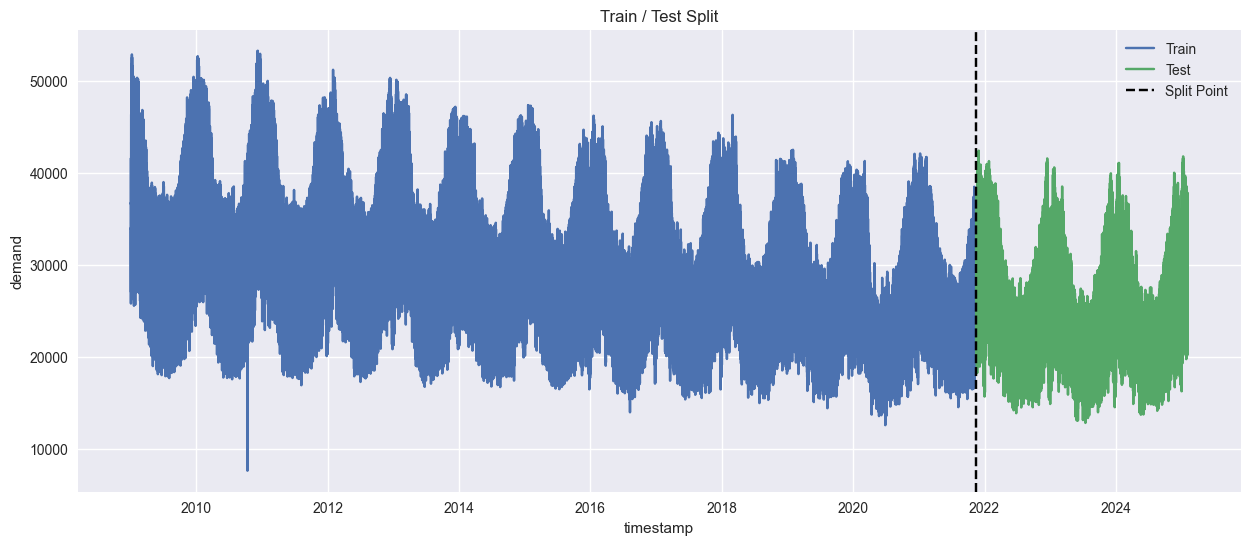

In [4]:
train = data.loc[:SPLIT_TIMESTAMP]
test = data.loc[SPLIT_TIMESTAMP:]

print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")

# Plot split
plt.figure(figsize=(15, 6))
sns.lineplot(data=train, x=train.index, y='demand', label='Train')
sns.lineplot(data=test, x=test.index, y='demand', label='Test')
plt.axvline(SPLIT_TIMESTAMP, color='black', linestyle='--', label='Split Point')
plt.title('Train / Test Split')
plt.legend()
plt.show()

## Parameter Tuning (Auto-ARIMA)

In [5]:
# Use recent subset
subset_size = 10000
search_subset = train['demand'].iloc[-subset_size:]

print("running auto_arima...")

auto_model = auto_arima(
    search_subset,
    seasonal=False,  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True
)

print(f"Best parameters found: {auto_model.order}")
print(auto_model.summary())

running auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=145522.624, Time=1.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=161385.357, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=146862.270, Time=0.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=154266.948, Time=1.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=161383.381, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=145646.702, Time=2.17 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=5.25 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=145195.868, Time=2.19 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=145281.385, Time=1.62 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=8.38 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=7.65 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=6.73 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=145227.199, Time=2.93 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=145197.728, Time=3.72 sec
 ARIMA(3,1,

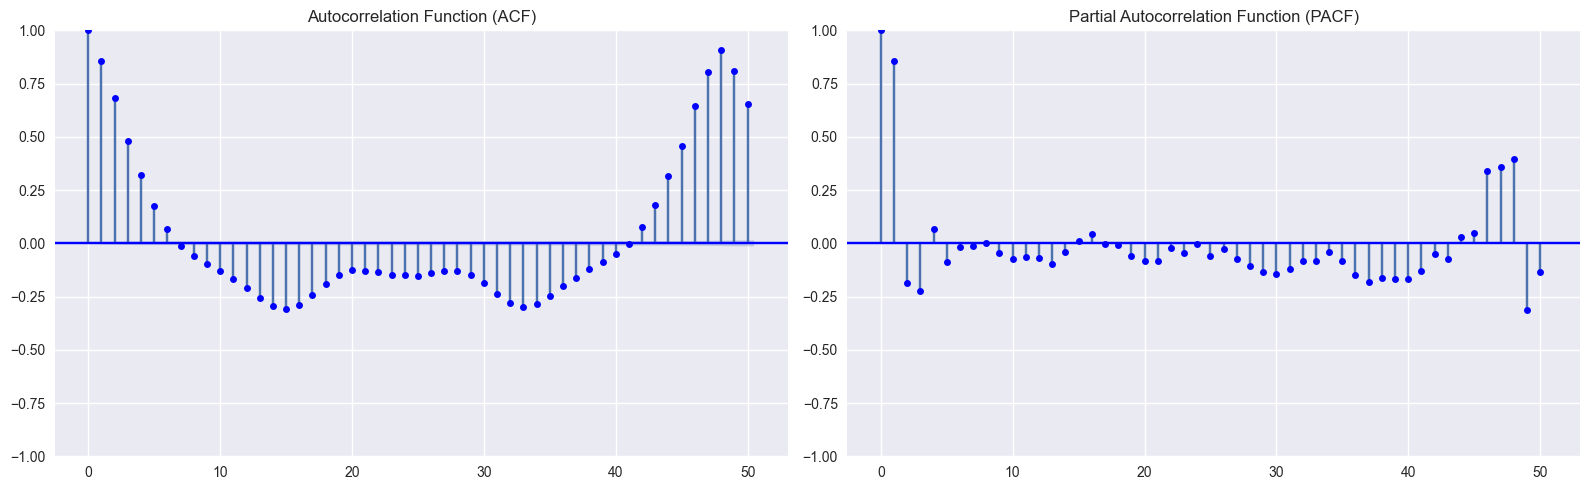

In [6]:
# Difference series
train_diff = train['demand'].diff().dropna()

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(train_diff, lags=50, ax=axes[0], title="Autocorrelation Function (ACF)", color='blue')
plot_pacf(train_diff, lags=50, ax=axes[1], title="Partial Autocorrelation Function (PACF)", color='blue')
plt.tight_layout()
plt.show()

## Train the final ARIMA Model

In [7]:
# Train the final model
order = auto_model.order
print("fitting model:", order)

arima_model = ARIMA(train['demand'], order=order)

arima_results = arima_model.fit()

print(arima_results.summary())

fitting model: (3, 1, 2)


c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:               225716
Model:                 ARIMA(3, 1, 2)   Log Likelihood            -1721847.939
Date:                Sat, 11 Apr 2026   AIC                        3443707.879
Time:                        23:35:59   BIC                        3443769.841
Sample:                    01-01-2009   HQIC                       3443726.020
                         - 11-16-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6100      0.003    229.173      0.000       0.605       0.615
ar.L2          0.5132      0.003    162.071      0.000       0.507       0.519
ar.L3         -0.3794      0.004   -105.863      0.0

## Generate Forecasts

In [8]:
# Forecast for the length of the test period
forecast_values = arima_results.forecast(steps=len(test)).values

# Align with test index
forecast = pd.Series(forecast_values, index=test.index)

print("done")
print(f"First 5 predictions:\n{forecast.head()}")

done
First 5 predictions:
timestamp
2021-11-16 09:30:00    33645.817366
2021-11-16 10:00:00    33353.022975
2021-11-16 10:30:00    33184.875387
2021-11-16 11:00:00    32975.360379
2021-11-16 11:30:00    32872.344923
dtype: float64


## Visualise Forecast vs Actual

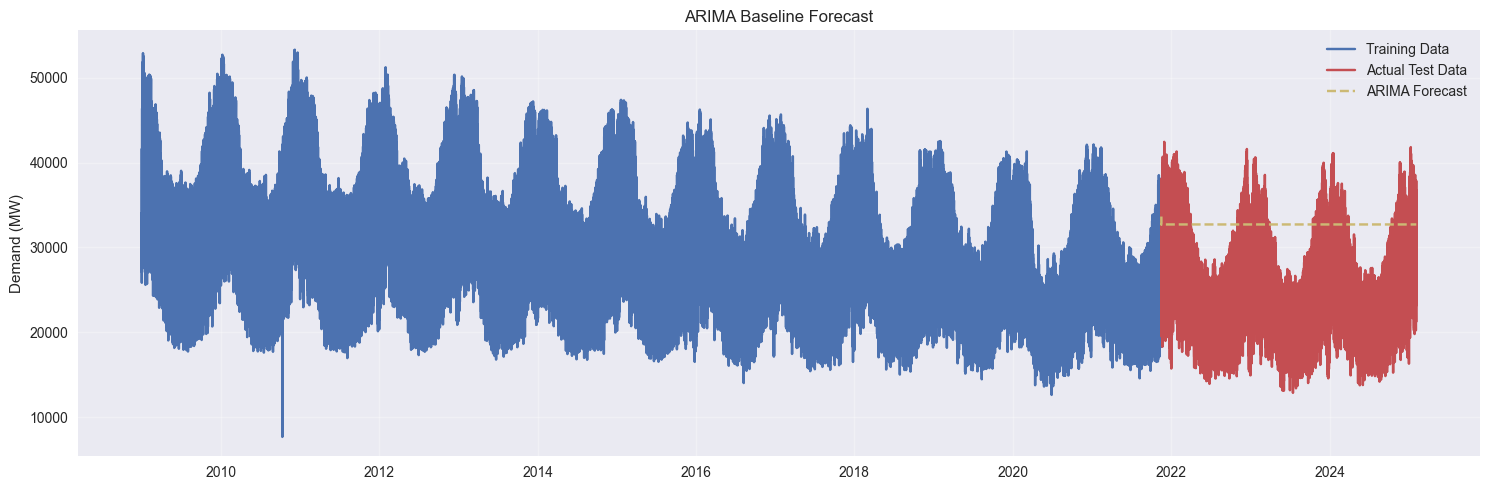

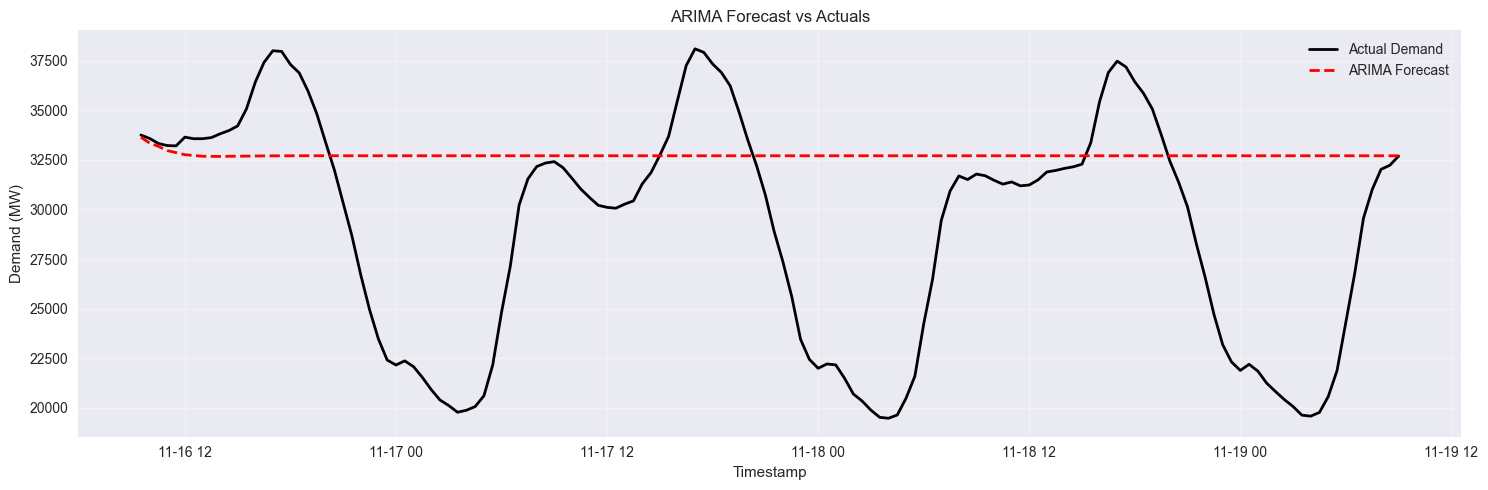

In [9]:
# Full timeline
plt.figure(figsize=(15, 5))
plt.plot(train.index, train['demand'], label="Training Data", color='#4C72B0')
plt.plot(test.index, test['demand'], label="Actual Test Data", color='#C44E52')
plt.plot(forecast.index, forecast, label="ARIMA Forecast", color='#CCB974', linestyle="--")
plt.title("ARIMA Baseline Forecast")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zoomed view (72 hours)
window = 144 

plt.figure(figsize=(15, 5))
plt.plot(test.index[:window], test['demand'].iloc[:window], label="Actual Demand", color='black', linewidth=2)
plt.plot(forecast.index[:window], forecast.iloc[:window], label="ARIMA Forecast", color='red', linestyle="--", linewidth=2)
plt.title("ARIMA Forecast vs Actuals")
plt.ylabel("Demand (MW)")
plt.xlabel("Timestamp")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Evaluation

In [10]:
eval_df = pd.DataFrame({
    'actual': test['demand'],
    'forecast': forecast
})

# Drop NaNs 
eval_df = eval_df.dropna()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(eval_df['actual'], eval_df['forecast']))
mae = mean_absolute_error(eval_df['actual'], eval_df['forecast'])
mape = mean_absolute_percentage_error(eval_df['actual'], eval_df['forecast'])

print(f"ARIMA RMSE: {rmse:.3f}")
print(f"ARIMA MAE:  {mae:.3f}")
print(f"ARIMA MAPE:  {mape:.3f}")

ARIMA RMSE: 9992.853
ARIMA MAE:  8794.179
ARIMA MAPE:  0.423


In [11]:
# Save results
os.makedirs('../results', exist_ok=True)
arima_metrics = {
    'model_name': 'ARIMA (Baseline)',
    'rmse': float(rmse),
    'mae': float(mae),
    'mape': float(mape) 
}
with open('../../results/arima_metrics.json', 'w') as f:
    json.dump(arima_metrics, f)
print("saved")

np.save('../../results/arima_preds.npy', forecast[:100]) 
print(" Predictions saved!")

# Save the model for the Flask API
arima_results.save('arima_model.pkl')
print(" ARIMA Model successfully saved as 'arima_model.pkl'!")

saved
 Predictions saved!
 ARIMA Model successfully saved as 'arima_model.pkl'!


## Store for Comparison

In [12]:
baseline_results = {
    "Model": "ARIMA",
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape
}

baseline_results

arima_results.save('arima_model.pkl')

print(f" Saved perfectly to: {os.path.abspath('arima_model.pkl')}")

 Saved perfectly to: c:\Users\ariel\OneDrive\Documents\GitHub\energy-consumption-forecasting\models\arima\arima_model.pkl
